# Decision Tree

In [0]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

# Model building
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow 
import mlflow.sklearn

In [0]:
X_train_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/x_train_delta3")
X_train = X_train_spark.toPandas()
X_train.drop(['company_names', 'cars_names', 'Engines', 'fuel_types', 'Price_Category', "Price_per_HP", "Price_per_Seat"], axis=1, inplace=True)

y_train_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/y_train_delta3")
y_train = y_train_spark.toPandas()

X_test_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/x_test_delta3")
X_test = X_test_spark.toPandas()
X_test.drop(['company_names', 'cars_names', 'Engines', 'fuel_types', 'Price_Category', "Price_per_HP", "Price_per_Seat"], axis=1, inplace=True)

y_test_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/y_test_delta3")
y_test = y_test_spark.toPandas()

In [0]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_split=4, random_state=42)

# Fit on full training set and save
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_split=4, random_state=42)

In [0]:
dt.score(X_train, y_train) * 100

97.23648813910751

In [0]:
dt.score(X_test, y_test) * 100

78.49255257964282

In [0]:
with mlflow.start_run() as run:

    model = DecisionTreeRegressor().fit(X_train, y_train)
    model.fit(X_train, y_train['cars_prices'])

    mlflow.log_metric('train score', model.score(X_train, y_train['cars_prices']))

    mlflow.sklearn.log_model(
        sk_model=model,
        name='model',
        registered_model_name='dr',
        input_example=X_train.head(5)
    )

🔗 View Logged Model at: https://dbc-ee0b89ab-29c3.cloud.databricks.com/ml/experiments/4366753362691855/models/m-111b121e63af4f00950dd02cd8023144?o=2522432660463639
Registered model 'dr' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '21' of model 'workspace.default.dr': https://dbc-ee0b89ab-29c3.cloud.databricks.com/explore/data/models/workspace/default/dr/version/21?o=2522432660463639


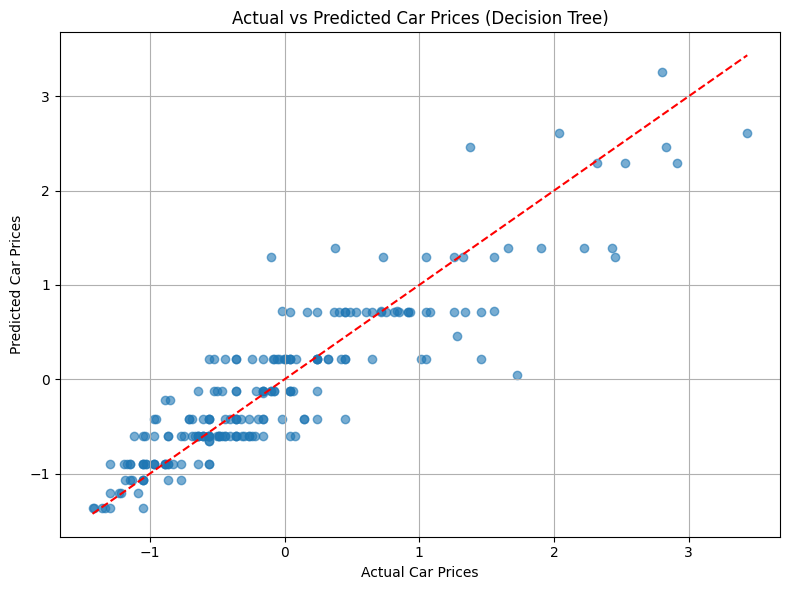

In [0]:
# Predict on test set
y_pred = dt.predict(X_test)

# Visualize actual vs predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test['cars_prices'], y_pred, alpha=0.6)
plt.xlabel('Actual Car Prices')
plt.ylabel('Predicted Car Prices')
plt.title('Actual vs Predicted Car Prices (Decision Tree)')
plt.plot([y_test['cars_prices'].min(), y_test['cars_prices'].max()],
         [y_test['cars_prices'].min(), y_test['cars_prices'].max()],
         color='red', linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()

In [0]:
results = []

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results.append([mae, mse, r2])

In [0]:
results = pd.DataFrame(results, columns=["MAE", "MSE", "R² Score"])
results

,MAE,MSE,R² Score
0,0.285011,0.166676,0.810742
